# Do the four colors of a trading bar tell you what happens next? 🚦
### Bill Williams' Market Facilitation Index — a 30-year-old retail rule that never got checked

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Green/Squat?: Busted](https://img.shields.io/badge/Green%2FSquat%3F-Busted-8b949e?style=flat-square)

Bill Williams, the trading author behind the "Alligator" and "chaos theory" school of technical analysis, built a simple ratio: how far price moved (High minus Low) divided by how much volume it took to move it. Cross that ratio's day-to-day direction against volume's own day-to-day direction and you get four "colors": **Green** — price and volume agree, the market is "in gear," the move should *continue*. **Squat** — lots of volume, no progress, the market is "coiling" before a *reversal*.

It's taught in trading courses to this day. Nobody seems to have actually checked it against 33 years of data. We did.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SPY headline + a 5-ETF basket (QQQ, DIA, IWM, XLE, GLD), raw daily bars, 1993→2026. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from market_facilitation_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BASKET = data.load_basket()
    SPY_BARS = BASKET["SPY"]
    DF = st.day_frame(SPY_BARS)
else:
    BASKET = SPY_BARS = DF = None
print("real cache present:", HAVE_REAL, "| tickers:", data.TICKERS,
      "| SPY bars:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-06-30', 'tickers': ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'GLD'], 'fp_spy': '77c7e57287b6', 'fp_qqq': 'f8a90001e6b4', 'fp_dia': '2b099f19b356', 'fp_iwm': 'c02ce892c294', 'fp_xle': 'fca8869d5f64', 'fp_gld': 'e20ec7413593', 'n_spy': 8410, 'n_classified': 8409, 'spy': {'green': (1954, 6.64, 4.19, 0.84, -4.29, -1.8, -0.85, 46.5), 'fade': (2002, 3.68, 5.1, -0.48, 2.35, -3.86, 2.08, 49.6), 'fake': (2256, 6.76, 4.02, 0.94, -6.07, -1.02, -1.74, 49.1), 'squat': (2196, 2.01, 5.73, -1.26, -1.19, -2.8, 0.54, 48.6)}, 'placebo_green_gap': -2.48, 'placebo_green_p': 0.4008, 'placebo_squat_gap': 1.6, 'placebo_squat_p': 0.5842, 'pooled': {'green': (8864, 5.56, 0.63, -3.03, -0.33, 48.5), 'fade': (9218, 5.43, 0.54, -1.16, 1.1, 48.8), 'fake': (11894, 6.83, 1.89, -4.88, -2.07, 49.2), 'squat': (11364, 1.32, -2.89, -1.0, 1.35, 48.3)}, 'per_ticker': {'SPY': (-0.85, 1954, 0.54, 2196), 'QQQ': (-0.37, 1699, 1.31, 1680), 'DIA': (-0.02, 1432, 0.92, 2057), 'IWM': (0.21, 1396, -0.13, 1800), 'XLE': (0.02, 1234, 0.58, 2168), 'GLD': (0.39, 1149, -0.23, 1463)}, 'timer': {'green': (0.33, 0.65, -3.63, -3.55, 52.0), 'squat_avoid': (0.61, 0.65, -0.966, -1.53, 55.5), 'sma': (0.75, 0.65, -0.719, -0.97, 0.5)}, 'cost_sweep': [(0.0, 0.45, -3.14), (1.0, 0.33, -3.55), (2.0, 0.21, -3.95), (5.0, -0.15, -5.17)], 'perm_gap': -0.314, 'perm_p': 0.211, 'syn_null_green_mean': 0.35, 'syn_null_green_sd': 0.87, 'syn_null_green_fire': 1, 'syn_null_squat_mean': -0.17, 'syn_null_squat_sd': 0.76, 'syn_null_squat_fire': 0, 'syn_planted_green_bps': 70.42, 'syn_planted_green_t': 17.23, 'syn_planted_squat_bps': -63.65, 'syn_planted_squat_t': -22.14}


real cache present: True | tickers: ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'GLD'] | SPY bars: 8410


## The answer first

| Question | Answer |
|---|---|
| Does a Green bar predict the next day continues the trend? | **No.** The "continuation score" on Green days is actually **negative** (-4.3 bps) — the opposite of what the rule claims — and it's nowhere close to statistically real. |
| Does a Squat bar predict a reversal? | **No.** Barely different from a normal day (-1.2 bps), and again not real statistically. |
| Does the sign at least agree across different markets? | **No.** Green is negative on SPY, QQQ and DIA but positive on IWM, XLE and GLD — a coin flip, not a pattern. |
| Can you trade the "ride the Green days" idea? | **You'd lose money doing it** — significantly worse than just holding the index, even before paying a single cent of trading costs. |

> Four colors, thirty years of data, zero signal.

## 1 · The claim

> *"When price range and volume both expand together, the market is 'in gear' — ride it. When volume explodes but price goes nowhere, the market is 'squatting,' loading up for a violent move — the trend is about to snap."*

It has the shape of a good idea: volume is supposed to confirm price moves, and BW-MFI turns that intuition into a simple, mechanical rule anyone can read off a chart with no math beyond "is this bar bigger or smaller than the last one, on more or less volume."

## 2 · So what?

If it worked, this would be one of the simplest tradeable edges on the desk: no model, no optimization, just four labels read straight off daily bars. It's taught as gospel in retail technical-analysis courses. If it's noise dressed up as a pattern, that's worth knowing too — and it's a template for how to check *any* categorical chart-pattern claim honestly.

## 3 · How would we even know?

- **Label every day.** Compute BW-MFI = (High−Low)/Volume for SPY and five other ETFs, compare it and volume to the day before, and sort every day into Green / Fade / Fake / Squat.
- **Score the next day.** For each color, does tomorrow's return tend to *continue* today's direction (a positive "continuation score") or *reverse* it (negative)?
- **The luck check.** Reshuffle which days get which color label 2,000 times — how often does a random subset of days score this well by chance?
- **The replication check.** Does the sign of the effect agree across six different, independently-traded markets?
- **The trade check.** Actually trade it — long only on Green days — and see if it beats simply holding the index, after costs.

## 4 · The teardown — let's actually look

**First, the headline.** Average continuation score by bar color on SPY — positive means "tomorrow agreed with today," negative means "tomorrow reversed it."

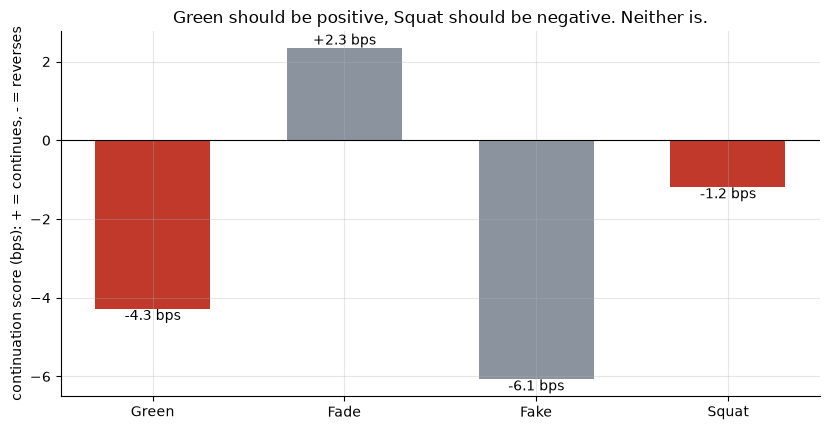

{'Green': -4.29, 'Fade': 2.35, 'Fake': -6.07, 'Squat': -1.19}


In [2]:
if HAVE_REAL:
    s = st.state_stats(DF)
    conts = [s[st_]['cont_bps'] for st_ in ['green', 'fade', 'fake', 'squat']]
else:
    conts = [R['spy'][st_][4] for st_ in ['green', 'fade', 'fake', 'squat']]
labels = ['Green', 'Fade', 'Fake', 'Squat']
cols = [RED if l in ('Green','Squat') else GREY for l in labels]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labels, conts, color=cols, width=.6)
for i, v in enumerate(conts):
    ax.annotate(f'{v:+.1f} bps', (i, v), ha='center', va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('continuation score (bps): + = continues, - = reverses')
ax.set_title('Green should be positive, Squat should be negative. Neither is.')
plt.tight_layout(); plt.show()
print({l: round(c, 2) for l, c in zip(labels, conts)})

Green should be **positive** (continuation) — it's **-4.3 bps**, negative, backwards. Squat should be clearly **negative** (reversal) — it's **-1.2 bps**, barely different from zero. Neither bar is even close to the *t* = 2 bar the desk requires to call something real, and a 2,000-shuffle placebo confirms both are indistinguishable from randomly relabeling the days (*p* = 0.40 for Green, 0.58 for Squat).

**Does it at least hold up on other markets?**

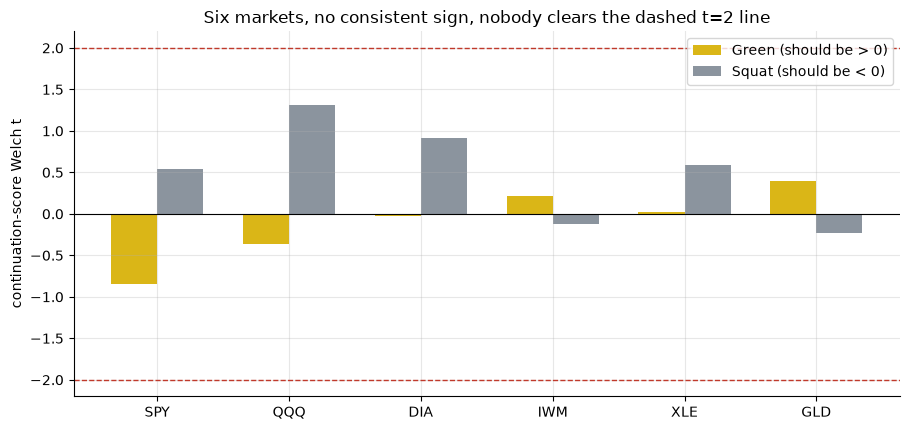

green t: {'SPY': -0.85, 'QQQ': -0.37, 'DIA': -0.02, 'IWM': 0.21, 'XLE': 0.02, 'GLD': 0.39}
squat t: {'SPY': 0.54, 'QQQ': 1.31, 'DIA': 0.92, 'IWM': -0.13, 'XLE': 0.58, 'GLD': -0.23}


In [3]:
tickers = ['SPY', 'QQQ', 'DIA', 'IWM', 'XLE', 'GLD']
if HAVE_REAL:
    gts, sts = [], []
    for t in tickers:
        d = st.day_frame(BASKET[t]); ss = st.state_stats(d)
        gts.append(ss['green']['welch_t_cont']); sts.append(ss['squat']['welch_t_cont'])
else:
    gts = [R['per_ticker'][t][0] for t in tickers]
    sts = [R['per_ticker'][t][2] for t in tickers]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
x = np.arange(len(tickers)); w = .35
ax.bar(x - w/2, gts, width=w, color=AMBER, label='Green (should be > 0)')
ax.bar(x + w/2, sts, width=w, color=GREY, label='Squat (should be < 0)')
ax.axhline(0, c='k', lw=.8)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks(x); ax.set_xticklabels(tickers)
ax.set_ylabel('continuation-score Welch t')
ax.set_title('Six markets, no consistent sign, nobody clears the dashed t=2 line')
ax.legend(); plt.tight_layout(); plt.show()
print('green t:', dict(zip(tickers, [round(v,2) for v in gts])))
print('squat t:', dict(zip(tickers, [round(v,2) for v in sts])))

The sign of "Green" flips between negative (SPY, QQQ, DIA) and positive (IWM, XLE, GLD) depending on which ETF you look at — and "Squat" does the same thing in reverse. That's the signature of noise, not a six-way replication of a real pattern.

**Finally, the trade.** What if you actually built a strategy — go long only on Green days, the "in gear, ride it" reading?

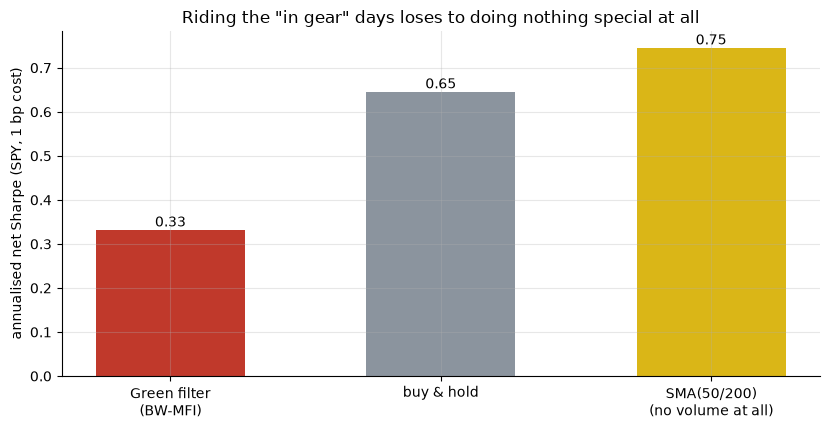

Green filter Sharpe 0.33 vs buy-hold 0.65 vs SMA 0.75


In [4]:
if HAVE_REAL:
    r = st.run_timer(DF, cost_bps=1.0)
    gs, bs = r['green']['sharpe_strat'], r['green']['sharpe_bench']
    ss_, bs2 = r['sma']['sharpe_strat'], r['sma']['sharpe_bench']
else:
    gs, bs = R['timer']['green'][0], R['timer']['green'][1]
    ss_, bs2 = R['timer']['sma'][0], R['timer']['sma'][1]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['Green filter\n(BW-MFI)', 'buy & hold', 'SMA(50/200)\n(no volume at all)'],
       [gs, bs, ss_], color=[RED, GREY, AMBER], width=.55)
for i, v in enumerate([gs, bs, ss_]):
    ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('annualised net Sharpe (SPY, 1 bp cost)')
ax.set_title('Riding the "in gear" days loses to doing nothing special at all')
plt.tight_layout(); plt.show()
print(f'Green filter Sharpe {gs:.2f} vs buy-hold {bs:.2f} vs SMA {ss_:.2f}')

The Green-only filter posts a net Sharpe of **0.33** against buy-and-hold's **0.65** — and the gap is statistically real (just not in the direction anyone selling the rule would want): it **loses significantly**, even *before* paying a single cent in trading costs. A plain two-line moving-average crossover, using none of BW-MFI's volume machinery, beats both at **0.75**.

## 5 · The verdict

- **Signal — None.** Neither Green's continuation claim nor Squat's reversal claim clears the statistical bar, both point the wrong way on the headline tape, and the sign isn't even stable across six different markets.
- **Tradability — Mirage.** The one tradeable version of the idea actively loses to simply holding the index — significantly, and before costs.
- **"Green flags continuation, Squat flags reversal"? — Busted.** Not weak, not mixed — busted, on every test we ran.

## 6 · Going further 🚪

- **Why might a plausible-sounding rule fail this completely?** BW-MFI's own four states are already unbalanced by construction — because MFI is a *ratio* of range to volume, a volume spike mechanically tends to *lower* MFI even when nothing informative is happening, which is exactly why Fake and Squat are the two most common colors in the data. The rule may be confusing a mechanical artefact of the ratio for a market signal.
- **A cleaner volume-confirmation test** would separate the ratio's mechanical bias from any genuine price-volume information — the natural sequel to this study.
- **Sibling studies:** the closest relative, [Ease of Movement](../../424-ease-of-movement/), tests the same range-over-volume ratio as a continuous signal (and finds a real but unremarkable trend effect, no better than a moving average) — worth reading next.

*Think the classifier itself is wrong, not the claim? The code is right here — fork it, change the state rule, show a net, certifiable edge after costs, then we'll talk.*